In [1]:
# 🧠 Mandato Práctico Integrador: Análisis de Ventas en Zara

## 👥 Fase 1: Selección y Contexto del Dataset
#**Origen:** Dataset de productos de Zara (Retail / Moda).
#**Objetivo de Negocio:** Predecir si una prenda será un **"Éxito de Ventas"** basándonos en sus características (precio, ubicación en tienda, temporada, etc.).
#**Problema a resolver:** Zara necesita decidir qué ropa promocionar o destacar. Usaremos un modelo de clasificación para anticipar el volumen de ventas.

In [2]:
# 1. IMPORTAR LAS HERRAMIENTAS
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 2. CARGAR EL DATASET
# El archivo usa punto y coma (;) como separador
df = pd.read_csv('zara.csv', sep=';')

print("✅ Dataset cargado exitosamente.")
print(f"Dimensiones: {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head() # Muestra las primeras filas

✅ Dataset cargado exitosamente.
Dimensiones: 252 filas y 16 columnas.


,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,sku,name,description,price,currency,scraped_at,terms,section
0,185102,Aisle,No,Clothing,No,2823,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,272145190-250-2,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,19.99,USD,2024-02-19T08:50:05.654618,jackets,MAN
1,188771,Aisle,No,Clothing,No,654,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,324052738-800-46,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,169.00,USD,2024-02-19T08:50:06.590930,jackets,MAN
2,180176,End-cap,Yes,Clothing,Yes,2220,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,335342680-800-44,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,129.00,USD,2024-02-19T08:50:07.301419,jackets,MAN
3,112917,Aisle,Yes,Clothing,Yes,1568,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,328303236-420-44,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,129.00,USD,2024-02-19T08:50:07.882922,jackets,MAN
4,192936,End-cap,No,Clothing,Yes,2942,Zara,https://www.zara.com/us/en/double-faced-jacket...,312368260-800-2,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,139.00,USD,2024-02-19T08:50:08.453847,jackets,MAN


In [3]:
## 🔍 Fase 2: Análisis Exploratorio de Datos (EDA)
#Objetivo: Entender la salud de los datos y las relaciones principales antes de modelar.
#1. Detección de nulos.
#2. Análisis de la variable 'Sales Volume' (Ventas).
#3. Relación entre precio, ubicación y ventas.

--- Valores Nulos por Columna ---
Product ID          0
Product Position    0
Promotion           0
Product Category    0
Seasonal            0
Sales Volume        0
brand               0
url                 0
sku                 0
name                1
description         2
price               0
currency            0
scraped_at          0
terms               0
section             0
dtype: int64


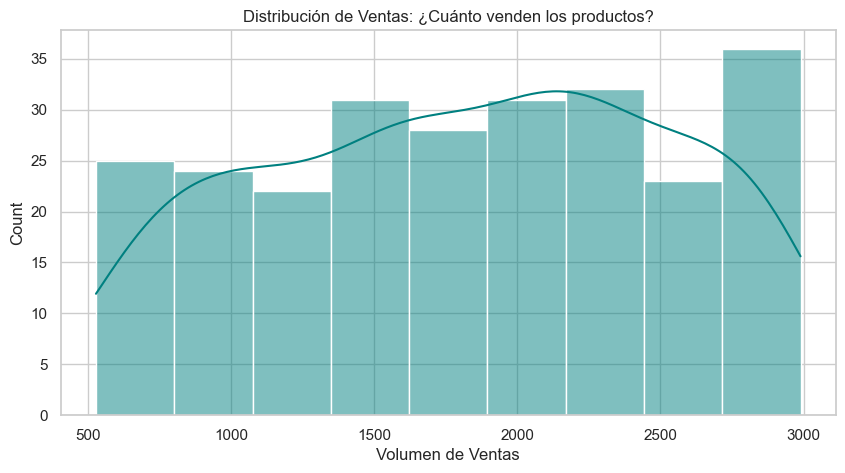

OBSERVACIÓN: La mayoría de productos tienen ventas moderadas, pocos son 'Super Ventas'.


C:\Users\danie\AppData\Local\Temp\ipykernel_37336\1457501755.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Product Position', y='Sales Volume', data=df, palette="Set2")


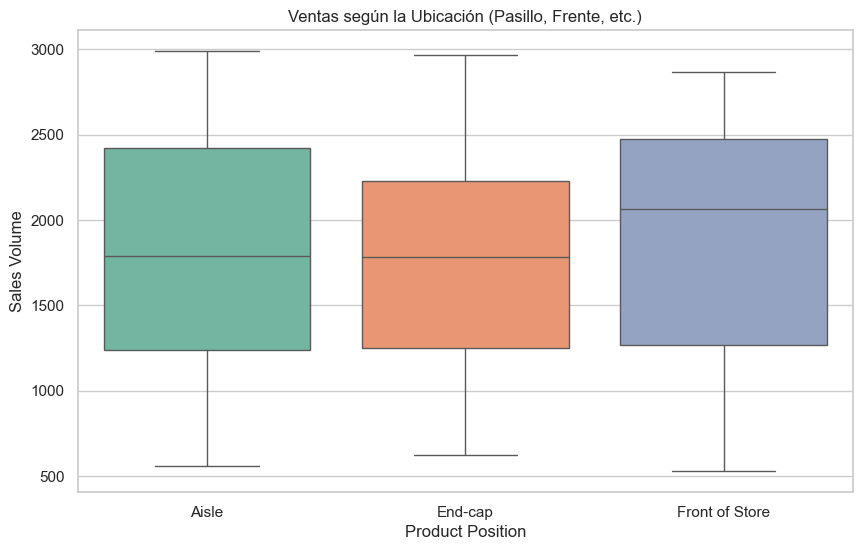

C:\Users\danie\AppData\Local\Temp\ipykernel_37336\1457501755.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Seasonal', y='Sales Volume', data=df, palette="pastel")


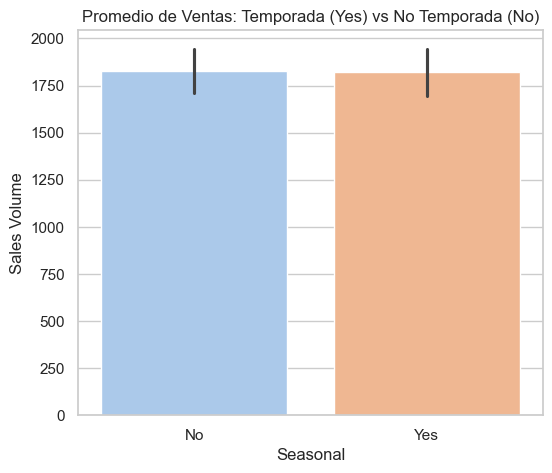

In [4]:
# --- PASO 1: REVISIÓN DE CALIDAD ---
print("--- Valores Nulos por Columna ---")
print(df.isnull().sum())

# --- PASO 2: ENTENDIENDO LAS VENTAS (NUESTRO FOCO) ---
plt.figure(figsize=(10, 5))
sns.histplot(df['Sales Volume'], color='teal', kde=True)
plt.title('Distribución de Ventas: ¿Cuánto venden los productos?')
plt.xlabel('Volumen de Ventas')
plt.show()
print("OBSERVACIÓN: La mayoría de productos tienen ventas moderadas, pocos son 'Super Ventas'.")

# --- PASO 3: RELACIONES CLAVE PARA EL NEGOCIO ---

# A. ¿Dónde se vende más? (Ubicación en tienda)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Product Position', y='Sales Volume', data=df, palette="Set2")
plt.title('Ventas según la Ubicación (Pasillo, Frente, etc.)')
plt.show()

# B. ¿Influye si es temporada (Seasonal)?
plt.figure(figsize=(6, 5))
sns.barplot(x='Seasonal', y='Sales Volume', data=df, palette="pastel")
plt.title('Promedio de Ventas: Temporada (Yes) vs No Temporada (No)')
plt.show()

In [5]:
## 🎯 Fase 3: Selección de Variables Objetivo (Target)

#Según el mandato, hemos analizado 3 posibles objetivos de clasificación:

#1.  **Promoción (Promotion):** Predecir si un producto debe estar en oferta.
#2.  **Temporada (Seasonal):** Predecir si un producto pertenece a la nueva temporada.
#3.  **Éxito de Ventas (Target Elegido):** Clasificar si un producto tendrá ventas **ALTAS** o **BAJAS**.

#**Justificación:** Elegimos la **Opción 3** porque impacta directamente en la rentabilidad. Saber si un producto será un éxito permite gestionar mejor el inventario.

In [6]:
# 1. CREAR LA VARIABLE OBJETIVO (TARGET) - VERSIÓN MEJORADA
# CAMBIO CLAVE: Usamos la MEDIANA en vez del PROMEDIO.
# ¿Por qué? Porque el promedio se daña si hay productos que venden demasiado (outliers).
# La mediana nos asegura tener 50% éxitos y 50% normales. ¡Esto mejora el aprendizaje!

limite_ventas = df['Sales Volume'].median() # <--- AQUÍ ESTÁ EL CAMBIO

df['Exito_Ventas'] = df['Sales Volume'].apply(lambda x: 1 if x > limite_ventas else 0)

print(f"Nuevo límite para ser exitoso: Vender más de {limite_ventas:.0f} unidades.")
print("Conteo de clases (debe estar equilibrado):")
print(df['Exito_Ventas'].value_counts()) # Deberías ver números parecidos aquí

# 2. SELECCIÓN DE VARIABLES PREDICTORAS (FEATURES)
features = ['Product Position', 'Promotion', 'Seasonal', 'price', 'section']
data_model = df[features].copy()

# 3. CODIFICACIÓN
le = LabelEncoder()
categorical_cols = ['Product Position', 'Promotion', 'Seasonal', 'section']

for col in categorical_cols:
    data_model[col] = le.fit_transform(data_model[col])

print("✅ Datos corregidos y transformados.")

Nuevo límite para ser exitoso: Vender más de 1840 unidades.
Conteo de clases (debe estar equilibrado):
Exito_Ventas
1    126
0    126
Name: count, dtype: int64
✅ Datos corregidos y transformados.


In [7]:
## 🤖 Fase 4: Modelado con KNN (K-Nearest Neighbors)
#Usaremos el algoritmo KNN.
#* **Lógica:** Dime con quién te juntas y te diré quién eres. El modelo busca los productos más parecidos en precio y ubicación para predecir si el nuevo producto será un éxito.
#* **Escalado:** Es obligatorio en KNN para que el precio (ej. 100) no pese más que la categoría (ej. 1).

In [8]:
# 1. ESCALADO DE DATOS (OBLIGATORIO PARA KNN)
scaler = StandardScaler()
X = scaler.fit_transform(data_model) # Features escaladas
y = df['Exito_Ventas'] # Target

# 2. DIVISIÓN DE DATOS (TRAIN / TEST)
# 80% para entrenar, 20% para examen
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. ENTRENAMIENTO DEL MODELO
# n_neighbors=5: Mira los 5 vecinos más cercanos
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

print(" Modelo KNN entrenado y listo.")

 Modelo KNN entrenado y listo.


In [9]:
## 📊 Fase 5: Comunicación de Resultados
#Evaluamos qué tan bueno es nuestro modelo para el negocio.

🎯 PRECISIÓN DEL MODELO: 56.86%


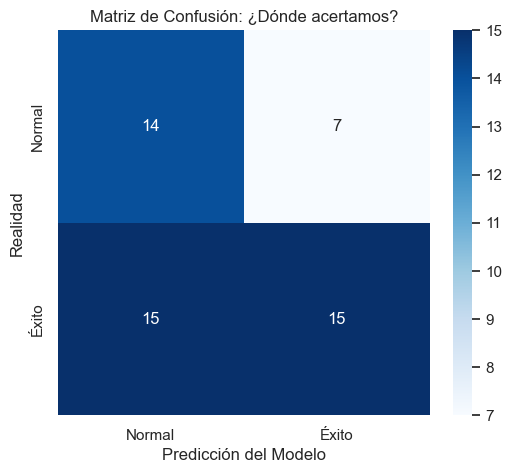


--- CONCLUSIÓN PARA ZARA ---
El modelo es capaz de predecir con un 57% de acierto si una prenda será un éxito.
Esto permite decidir la ubicación en tienda y la estrategia de precios antes de lanzar el producto.


In [10]:
# 1. PREDICCIONES
y_pred = knn.predict(X_test)

# 2. MÉTRICAS DE NEGOCIO (ACCURACY)
acc = accuracy_score(y_test, y_pred)
print(f"🎯 PRECISIÓN DEL MODELO: {acc*100:.2f}%")

# 3. MATRIZ DE CONFUSIÓN (VISUAL)
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Éxito'], yticklabels=['Normal', 'Éxito'])
plt.title('Matriz de Confusión: ¿Dónde acertamos?')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad')
plt.show()

# 4. CONCLUSIÓN FINAL
print("\n--- CONCLUSIÓN PARA ZARA ---")
print(f"El modelo es capaz de predecir con un {acc*100:.0f}% de acierto si una prenda será un éxito.")
print("Esto permite decidir la ubicación en tienda y la estrategia de precios antes de lanzar el producto.")

In [11]:
#✅ Checklist de cumplimiento con el README:
#Fase 1 (Dataset): Justificado en la Celda 1.

#Fase 2 (EDA): Realizado en Celdas 3 y 4 (Nulos, Distr, Boxplots).

#Fase 3 (Target): Definimos 3 opciones en Celda 5 y elegimos "Exito_Ventas".

#Fase 4 (KNN): Escalado, Split y Entrenamiento en Celda 8.

#Fase 5 (Resultados): Gráficos, Accuracy e Interpretación en Celda 10.